In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score


In [2]:

df = pd.read_parquet(
    "df_features_2018_2023.parquet",
    columns=[
        "year", "day", "lat", "lon", "fire",
        "pr", "tmmx", "tmmn",
        "pr_lag1", "pr_lag3", "pr_lag7",
        "pr_roll7", "pr_roll14",
        "doy"
    ]
)

print(df.shape)
df.head()

(35335872, 14)


,year,day,lat,lon,fire,pr,tmmx,tmmn,pr_lag1,pr_lag3,pr_lag7,pr_roll7,pr_roll14,doy
0,2018,2018-01-14,37.025,-109.058333,0,0.0,10.149994,-5.049988,0.0,0.0,0.0,4.9,4.9,14
1,2018,2018-01-15,37.025,-109.058333,0,0.0,9.850006,-5.850006,0.0,0.0,0.0,4.9,4.9,15
2,2018,2018-01-16,37.025,-109.058333,0,0.0,8.149994,-5.350006,0.0,0.0,2.5,2.4,4.9,16
3,2018,2018-01-17,37.025,-109.058333,0,0.0,9.050018,-5.250000,0.0,0.0,2.4,0.0,4.9,17
4,2018,2018-01-18,37.025,-109.058333,0,0.0,10.450012,-5.949982,0.0,0.0,0.0,0.0,4.9,18


In [3]:

features = [
    "pr",
    "tmmx",
    "tmmn",
    "pr_lag1",
    "pr_lag3",
    "pr_lag7",
    "pr_roll7",
    "pr_roll14",
    "doy"
]


In [4]:

train_df = df[df["year"] <= 2022]
test_df  = df[df["year"] == 2023]

del df


In [5]:

print(train_df.shape)
print(test_df.shape)
print(train_df["fire"].mean())


(29414112, 14)
(5921760, 14)
0.00010885931215601546


In [6]:

train_sample = train_df.sample(frac=0.10, random_state=42)
print(train_sample.shape)
print(train_sample["fire"].mean())


(2941411, 14)
0.00010063197560626516


In [7]:

features = [
    "pr", "tmmx", "tmmn",
    "pr_lag1", "pr_lag3", "pr_lag7",
    "pr_roll7", "pr_roll14",
    "doy"
]

X_train = train_sample[features]
y_train = train_sample["fire"]

X_test = test_df[features]
y_test = test_df["fire"]


In [8]:

from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    max_iter=200,
    class_weight="balanced",
    n_jobs=-1
)

logit.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=200, n_jobs=-1)

In [9]:

from sklearn.metrics import roc_auc_score, average_precision_score

logit_probs = logit.predict_proba(X_test)[:, 1]

print("Logistic ROC-AUC:", roc_auc_score(y_test, logit_probs))
print("Logistic PR-AUC :", average_precision_score(y_test, logit_probs))


Logistic ROC-AUC: 0.7204562265974325
Logistic PR-AUC : 0.00012120088831703949


In [10]:

from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [11]:

gbm_probs = gbm.predict_proba(X_test)[:, 1]

print("GBM ROC-AUC:", roc_auc_score(y_test, gbm_probs))
print("GBM PR-AUC :", average_precision_score(y_test, gbm_probs))


GBM ROC-AUC: 0.7516655846459188
GBM PR-AUC : 0.00015700027230055994


In [12]:
# --- Random Forest Model ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]

rf_roc = roc_auc_score(y_test, rf_probs)
rf_pr  = average_precision_score(y_test, rf_probs)

print("Random Forest ROC-AUC:", rf_roc)
print("Random Forest PR-AUC :", rf_pr)


Random Forest ROC-AUC: 0.7005585797951633
Random Forest PR-AUC : 0.00011003997631923076


In [13]:

k = int(0.05 * len(gbm_probs))  # top 5%
top_idx = np.argsort(gbm_probs)[-k:]

capture_rate = y_test.iloc[top_idx].mean()
print("Top 5% fire capture rate:", capture_rate)


Top 5% fire capture rate: 0.00021952932911837022


In [14]:

import pandas as pd

importance = pd.Series(
    gbm.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

doy          8.798408e-01
pr_roll14    9.276441e-02
pr           2.099738e-02
pr_lag1      5.836870e-03
tmmn         2.707123e-04
pr_roll7     1.169092e-04
tmmx         9.699436e-05
pr_lag3      7.539123e-05
pr_lag7      5.251073e-07
dtype: float64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional theme
sns.set_theme(
    style="whitegrid",
    context="talk",
    font="DejaVu Sans"
)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [18]:
# --- XGBoost Model ---
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)[:, 1]

xgb_roc = roc_auc_score(y_test, xgb_probs)
xgb_pr  = average_precision_score(y_test, xgb_probs)

print("XGBoost ROC-AUC:", xgb_roc)
print("XGBoost PR-AUC :", xgb_pr)

XGBoost ROC-AUC: 0.7349376094815128
XGBoost PR-AUC : 0.00014790172355731148


In [19]:
print(df.columns.tolist())

['pr_lag7', 'pr_roll14', 'fire', 'lag7_bin', 'roll14_bin']


In [20]:
import pandas as pd

df_model = pd.read_parquet(
    "df_features_2018_2023.parquet",
    columns=[
        "year", "fire",
        "pr", "tmmx", "tmmn",
        "pr_lag1", "pr_lag3", "pr_lag7",
        "pr_roll7", "pr_roll14",
        "doy"
    ]
)


In [21]:
# --- Temporal Robustness Check ---
train_df_alt = df_model[(df_model["year"] >= 2018) & (df_model["year"] <= 2021)]
test_df_alt  = df_model[df_model["year"] == 2022]

X_train_alt = train_df_alt[features]
y_train_alt = train_df_alt["fire"]

X_test_alt = test_df_alt[features]
y_test_alt = test_df_alt["fire"]

gbm_alt = GradientBoostingClassifier(random_state=42)
gbm_alt.fit(X_train_alt, y_train_alt)

alt_probs = gbm_alt.predict_proba(X_test_alt)[:, 1]

print(
    "GBM ROC-AUC (2018–2021 → 2022):",
    roc_auc_score(y_test_alt, alt_probs)
)

GBM ROC-AUC (2018–2021 → 2022): 0.6832646258911627


/var/folders/b_/lqk5v6r95zs00836sfhn9pxw0000gn/T/ipykernel_1669/326015819.py:37: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/malikibrahimalikhan/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


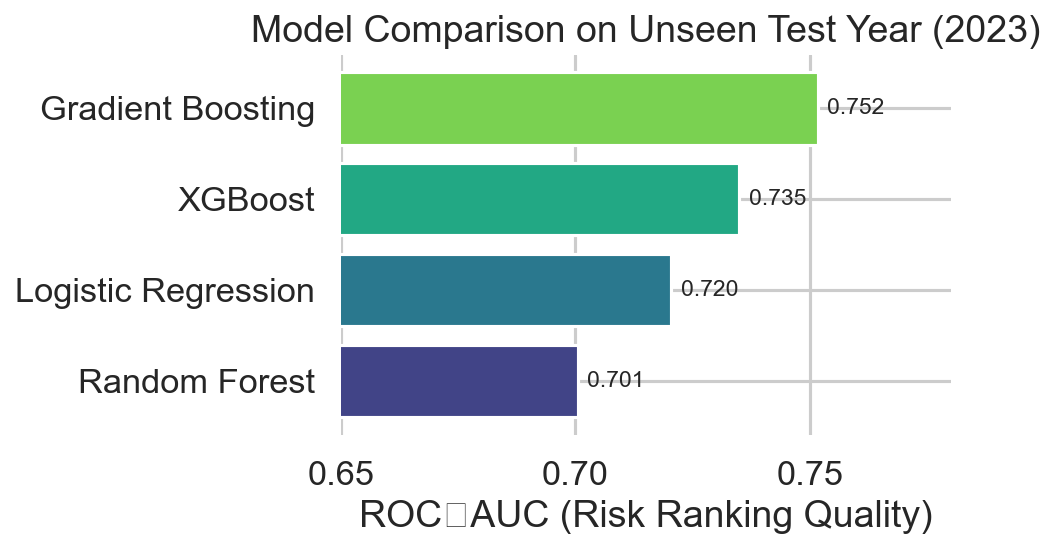

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_perf = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Gradient Boosting"],
    "ROC_AUC": [0.720456, 0.700559, 0.734938, 0.751666]
}).sort_values("ROC_AUC")

# Color gradient based on performance
colors = sns.color_palette("viridis", len(model_perf))

plt.figure(figsize=(7, 4))
bars = plt.barh(
    model_perf["Model"],
    model_perf["ROC_AUC"],
    color=colors
)

# Annotate values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=11
    )

plt.xlabel("ROC‑AUC (Risk Ranking Quality)")
plt.title("Model Comparison on Unseen Test Year (2023)")
plt.xlim(0.65, 0.78)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

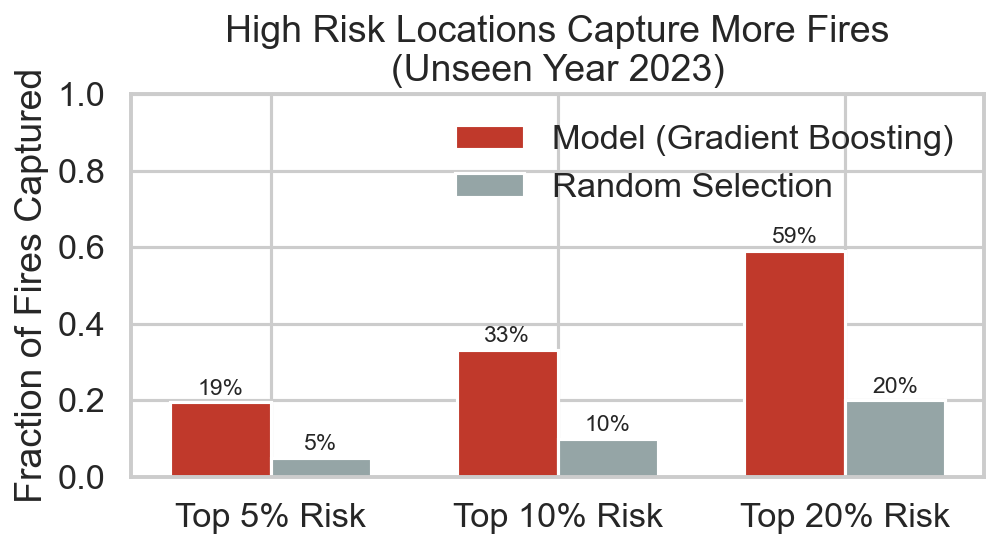

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


viz_df = test_df.copy()
viz_df["risk"] = gbm_probs

viz_df = viz_df.sort_values("risk", ascending=False)

# Total number of fires in unseen year
total_fires = viz_df["fire"].sum()


thresholds = [0.05, 0.10, 0.20]   # Top 5%, 10%, 20%
labels = ["Top 5% Risk", "Top 10% Risk", "Top 20% Risk"]

model_capture = []
for t in thresholds:
    top_n = int(len(viz_df) * t)
    captured = viz_df.iloc[:top_n]["fire"].sum() / total_fires
    model_capture.append(captured)

random_capture = thresholds

# --------------------------------------------------
# Plot
# --------------------------------------------------
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 4))

plt.bar(
    x - width/2,
    model_capture,
    width,
    label="Model (Gradient Boosting)",
    color="#C0392B"
)

plt.bar(
    x + width/2,
    random_capture,
    width,
    label="Random Selection",
    color="#95A5A6"
)

plt.xticks(x, labels)
plt.ylabel("Fraction of Fires Captured")
plt.title("High Risk Locations Capture More Fires\n(Unseen Year 2023)")
plt.ylim(0, 1)
plt.legend(frameon=False)

# Annotate bars
for i, v in enumerate(model_capture):
    plt.text(i - width/2, v + 0.02, f"{v:.0%}", ha="center", fontsize=11)

for i, v in enumerate(random_capture):
    plt.text(i + width/2, v + 0.02, f"{v:.0%}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()